# **Data Preprocessing**

## **Install pip**
---
Perintah `! pip install pyod` digunakan untuk mengunduh PyOD (Python Outlier Detection), sebuah pustaka Python yang dibuat khusus untuk mengenali outlier atau anomali. PyOD menyajikan lebih dari 30 algoritma terkenal, seperti *Isolation Forest*, *Local Outlier Factor (LOF)*, *Angle-based Outlier Detection (ABOD)*, kNN, PCA, dan *One-Class SVM*. Dengan hadirnya pustaka ini, analisis data menjadi lebih mudah karena pengguna dapat dengan cepat menemukan data yang tidak biasa. Setelah diinstal, PyOD dapat langsung digunakan di Jupyter Notebook atau Google Colab untuk membantu kegiatan *preprocessing* dan analisis anomali.


In [ ]:
!pip install pyod


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 8.3 MB/s eta 0:00:00


In [ ]:
!pip install pycaret[full]


Perintah `! pip install pycaret[full]` digunakan untuk menginstal PyCaret beserta semua ketergantungan tambahan secara lengkap. Simbol `! ` digunakan saat perintah dieksekusi di Jupyter Notebook atau Google Colab, dan `pip install` berfungsi untuk mengunduh dan memasang paket dari PyPI. PyCaret adalah library machine learning dengan kode rendah yang menyederhanakan proses kerja mulai dari pengolahan awal data, pelatihan, penyesuaian, hingga penerapan model. Dengan menambahkan pilihan `[full]`, semua modul tambahan seperti NLP, deret waktu, deteksi anomali, pemahaman model, visualisasi, dan koneksi ke database akan secara otomatis diinstal, sehingga pengguna dapat memanfaatkan PyCaret dengan fitur-fitur yang lebih lengkap dibandingkan instalasi standar.

## **Preprocessing outlier menggunakan 3 metode**

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.abod import ABOD

# === Load Dataset Iris ===
iris = load_iris(as_frame=True)
df = iris.frame.drop(columns=["target"])  # hanya feature
print("Dataset awal:", df.shape)

# === Fungsi Hapus Outlier ===
def hapus_outlier(data, metode="iforest", contamination=0.05):
    """
    Hapus outlier dari dataset menggunakan:
    - iforest : Isolation Forest
    - lof     : Local Outlier Factor
    - abod    : Angle-Based Outlier Detection
    """
    if metode == "iforest":
        detector = IForest(contamination=contamination, random_state=42)
    elif metode == "lof":
        detector = LOF(contamination=contamination)
    elif metode == "abod":
        detector = ABOD(contamination=contamination)
    else:
        raise ValueError("Metode tidak dikenali. Pilih: iforest, lof, abod")

    # Fit model
    detector.fit(data)
    y_pred = detector.labels_  # 0 = inlier, 1 = outlier

    # Hapus outlier
    data_clean = data[y_pred == 0]

    return data_clean, y_pred

# === Coba dengan 3 metode ===
for metode in ["iforest", "lof", "abod"]:
    clean_df, labels = hapus_outlier(df, metode=metode, contamination=0.05)
    print(f"\nMetode: {metode.upper()}")
    print("Jumlah data awal :", df.shape[0])
    print("Jumlah data bersih:", clean_df.shape[0])
    print("Jumlah outlier   :", sum(labels))


Dataset awal: (150, 4)

Metode: IFOREST
Jumlah data awal : 150
Jumlah data bersih: 142
Jumlah outlier   : 8

Metode: LOF
Jumlah data awal : 150
Jumlah data bersih: 142
Jumlah outlier   : 8

Metode: ABOD
Jumlah data awal : 150
Jumlah data bersih: 142
Jumlah outlier   : 8


Program ini memanfaatkan dataset Iris untuk mendeteksi dan menghapus outlier dengan tiga pendekatan berbeda dari pustaka PyOD. Data diambil menggunakan load\_iris dari scikit-learn, dan hanya memanfaatkan fitur numeriknya (tanpa menyertakan label target).

Sebuah fungsi bernama hapus\_outlier() dibuat untuk menerima data serta metode yang dipilih. Tiga metode yang tersedia adalah:

* **Isolation Forest (iforest)**, yang mengidentifikasi outlier melalui pemisahan data secara acak menggunakan pohon,
* **Local Outlier Factor (lof)**, yang mengevaluasi kerapatan di sekitar titik untuk menemukan titik yang terisolasi,
* **Angle-Based Outlier Detection (abod)**, yang menganalisis variasi sudut antar titik untuk mengidentifikasi anomali.

Setelah memilih model yang sesuai metode, fungsi akan melatih detektor (fit) dan menghasilkan label (labels\_), di mana 0 menunjukkan data normal dan 1 menandakan outlier. Data yang teridentifikasi sebagai outlier kemudian dihilangkan, sehingga hanya menyisakan dataset yang bersih (data\_clean).

Di bagian akhir, fungsi tersebut dijalankan dengan ketiga metode itu. Hasil yang ditampilkan mencakup jumlah data sebelum proses, jumlah data setelah penghapusan outlier, serta total outlier yang terdeteksi. Ini memungkinkan perbandingan efektivitas setiap algoritma dalam menemukan data yang menyimpang.

## **Visualisasi hasil data**

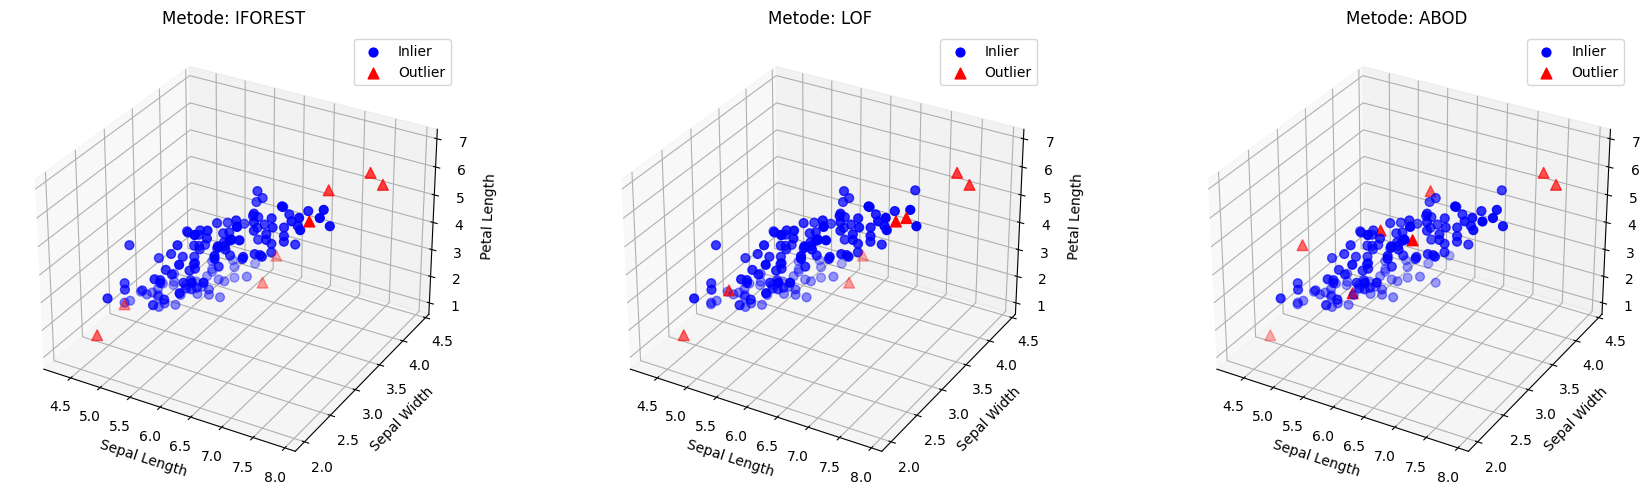

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.abod import ABOD

# === Load Dataset Iris ===
iris = load_iris(as_frame=True)
df = iris.frame.drop(columns=["target"])  # hanya features

# === Fungsi Hapus Outlier ===
def hapus_outlier(data, metode="iforest", contamination=0.05):
    if metode == "iforest":
        detector = IForest(contamination=contamination, random_state=42)
    elif metode == "lof":
        detector = LOF(contamination=contamination)
    elif metode == "abod":
        detector = ABOD(contamination=contamination)
    else:
        raise ValueError("Metode tidak dikenali. Pilih: iforest, lof, abod")

    detector.fit(data)
    y_pred = detector.labels_  # 0=inlier, 1=outlier
    return y_pred

# === Plot 3D hasil dari 3 metode ===
fig = plt.figure(figsize=(18, 5))
metode_list = ["iforest", "lof", "abod"]

for i, metode in enumerate(metode_list, 1):
    labels = hapus_outlier(df, metode=metode, contamination=0.05)

    ax = fig.add_subplot(1, 3, i, projection='3d')
    ax.set_title(f"Metode: {metode.upper()}")

    # Plot inlier
    inliers = df[labels == 0]
    ax.scatter(inliers.iloc[:, 0], inliers.iloc[:, 1], inliers.iloc[:, 2],
               c="blue", marker="o", s=40, label="Inlier")

    # Plot outlier
    outliers = df[labels == 1]
    ax.scatter(outliers.iloc[:, 0], outliers.iloc[:, 1], outliers.iloc[:, 2],
               c="red", marker="^", s=60, label="Outlier")

    ax.set_xlabel("Sepal Length")
    ax.set_ylabel("Sepal Width")
    ax.set_zlabel("Petal Length")
    ax.legend()

plt.tight_layout()
plt.show()


Kode ini digunakan untuk membandingkan hasil deteksi anomali pada dataset Iris dengan tiga teknik yang berbeda: Isolation Forest (iforest), Local Outlier Factor (lof), dan Angle-Based Outlier Detection (abod). Dataset Iris dimulai dengan memuatnya menggunakan `load_iris`, kemudian hanya fitur numeriknya yang digunakan dalam analisis. Fungsi `hapus_outlier()` dirancang untuk menerima data serta metode yang dipilih. Setelah model diterapkan, label prediksi diperoleh (`labels_`), di mana `0` menunjukkan inlier (data biasa) dan `1` menunjukkan outlier.

Pada bagian akhir kode, dibuat tiga visualisasi 3D subplot menggunakan matplotlib, masing-masing mewakili satu metode. Tiga fitur yang digunakan sebagai sumbu adalah Sepal Length, Sepal Width, dan Petal Length. Titik data yang dianggap normal ditampilkan dengan simbol lingkaran berwarna biru (`o`), sedangkan titik yang terdeteksi sebagai outlier ditandai dengan segitiga merah (`^`). Dengan visualisasi ini, kita dapat segera melihat perbedaan hasil deteksi anomali dari ketiga algoritma dalam ruang tiga dimensi pada dataset Iris.